# 1. Introduction

Hệ thống phân tích đánh giá sản phẩm đa phương thức sử dụng hai mô hình xử lý hình ảnh là CLIP và ResNet50 để tối ưu hóa quá trình kiểm định chất lượng hình ảnh từ đánh giá của khách hàng. Mục tiêu của quá trình đánh giá chéo này là đo lường hiệu năng và so sánh khả năng nhận diện hình ảnh giữa hai mô hình trên cùng một tập dữ liệu thử nghiệm.

Mô hình CLIP được áp dụng ở giai đoạn lọc ban đầu với vai trò phát hiện các hình ảnh không liên quan hoặc hình ảnh rác. Các hình ảnh này bao gồm ảnh chụp màn hình điện thoại, ảnh hóa đơn thanh toán, ảnh chụp thẻ cào điện thoại, hoặc hình ảnh có nền trắng trơn không chứa sản phẩm. Việc sử dụng CLIP giúp loại bỏ nhanh chóng các hình ảnh không mang giá trị thông tin trước khi đưa vào các bước phân tích sâu hơn.

Mô hình ResNet50 đóng vai trò nhận diện các lỗi vật lý cụ thể trên sản phẩm như móp méo, trầy xước, nứt vỡ, rách bao bì, hoặc sai màu sắc sản phẩm. ResNet50 đã được tinh chỉnh bằng phương pháp học chuyển tiếp trên tập dữ liệu sản phẩm lỗi để tối ưu hóa khả năng phát hiện các đặc trưng thị giác chi tiết. Quá trình đánh giá chéo này sẽ giúp xác định điểm mạnh và điểm yếu của từng mô hình trong hệ thống phân tích.


# 2. Project Structure and Configuration

Cấu trúc dự án bao gồm thư mục lưu trữ mã nguồn của bộ xử lý hình ảnh và thư mục lưu trữ các mô hình đã huấn luyện. Trọng số của mô hình ResNet50 được lưu tại đường dẫn mặc định trong thư mục models của công cụ AI. Tập dữ liệu thử nghiệm được tổ chức thành hai nhóm riêng biệt là sản phẩm lỗi và sản phẩm bình thường để phục vụ quá trình đánh giá hiệu năng.


In [1]:
# Imports, logging configuration and reproducibility settings
import os
import sys
import shutil
import logging
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score
from tqdm import tqdm

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Configure structured logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[logging.StreamHandler(sys.stdout)]
)
logger = logging.getLogger("ErrorAnalysis")

# Ensure project root is in path
sys.path.append(os.getcwd())

# Define paths
data_dir = "data/processed"
resnet_model_path = "ai_engine/models/resnet50_defect.pth"
output_dir = "data/error_analysis"

# Robustness check: Verify file and directory existence
if not os.path.exists(resnet_model_path):
    logger.error(f"ResNet50 model checkpoint not found at {resnet_model_path}")
    raise FileNotFoundError(f"Missing model checkpoint: {resnet_model_path}")

if not os.path.exists(data_dir):
    logger.error(f"Data directory not found at {data_dir}")
    raise FileNotFoundError(f"Missing data directory: {data_dir}")

# Create output directories
os.makedirs(os.path.join(output_dir, "clip", "false_positives"), exist_ok=True)
os.makedirs(os.path.join(output_dir, "clip", "false_negatives"), exist_ok=True)
os.makedirs(os.path.join(output_dir, "resnet50", "false_positives"), exist_ok=True)
os.makedirs(os.path.join(output_dir, "resnet50", "false_negatives"), exist_ok=True)
os.makedirs(os.path.join(output_dir, "resnet50", "wrong_classes"), exist_ok=True)

logger.info("Project paths and directories verified and configured successfully.")


2026-05-25 17:38:10,588 - INFO - Project paths and directories verified and configured successfully.


# 3. Dataset Loading

Tập dữ liệu kiểm thử được trích xuất trực tiếp từ cấu hình phân tách dữ liệu của hệ thống. Quá trình phân tách sử dụng phương pháp chia ngẫu nhiên phân tầng để đảm bảo tỷ lệ giữa nhóm sản phẩm lỗi và nhóm sản phẩm bình thường được duy trì đồng đều giữa tập huấn luyện và tập kiểm thử. Việc sử dụng mã hạt giống cố định giúp đảm bảo kết quả đánh giá có khả năng tái lặp trong các lần thực hiện tiếp theo.

## Dataset Imbalance Analysis
Hiện tượng mất cân bằng dữ liệu giữa các lớp là thách thức lớn đối với các bài toán phát hiện khuyết tật sản phẩm. Trong đó số lượng sản phẩm bình thường vượt trội hơn nhiều so với số lượng sản phẩm lỗi. Sự chênh lệch lớn này có thể dẫn đến hiện tượng suy giảm Recall đối với lớp thiểu số (lớp lỗi) do mô hình bị định kiến bởi lớp đa số (lớp bình thường). Phân tích thống kê dưới đây định lượng tỷ lệ mất cân bằng dữ liệu để đưa ra các biện pháp hiệu chỉnh phù hợp.


C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-05-25 17:38:13,184 - INFO - Loaded validation set: 743 samples.


2026-05-25 17:38:13,186 - INFO - Normal (no-defect) samples: 724


2026-05-25 17:38:13,186 - INFO - Defect samples: 19


2026-05-25 17:38:13,187 - INFO - Dataset imbalance ratio: 38.11 to 1


D:\Temp\ipykernel_2144\1537949204.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Normal (no-defect)", "Defect"], y=[n_normal, n_defect], palette="viridis")


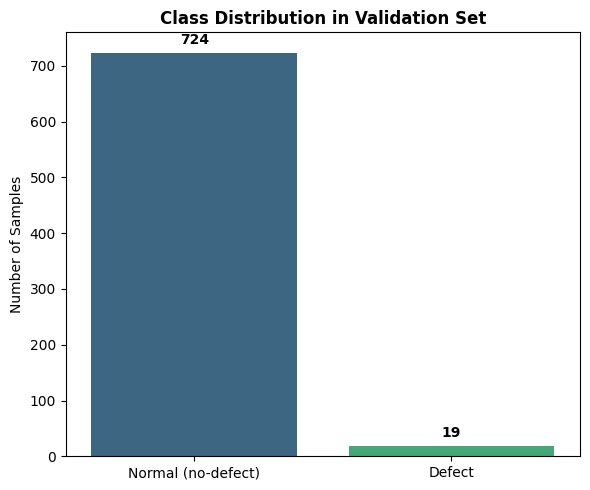

In [2]:
# Load dataset splits using the existing project dataloader logic
from ai_engine.image_processing.defect_detection import get_dataloaders

# Retrieve val loader using standard configuration (val_split=0.2, seed=42)
_, val_loader = get_dataloaders(data_dir=data_dir, batch_size=32, val_split=0.2, seed=42)
val_subset = val_loader.dataset
val_indices = val_subset.indices
val_dataset = val_subset.dataset

# Collect image paths and ground truth labels
image_paths = [str(val_dataset.image_paths[idx]) for idx in val_indices]
true_labels = [val_dataset.labels[idx] for idx in val_indices]

logger.info(f"Loaded validation set: {len(image_paths)} samples.")
n_normal = true_labels.count(0)
n_defect = true_labels.count(1)
imbalance_ratio = n_normal / n_defect if n_defect > 0 else 0

logger.info(f"Normal (no-defect) samples: {n_normal}")
logger.info(f"Defect samples: {n_defect}")
logger.info(f"Dataset imbalance ratio: {imbalance_ratio:.2f} to 1")

# Plotting class distribution
plt.figure(figsize=(6, 5))
sns.barplot(x=["Normal (no-defect)", "Defect"], y=[n_normal, n_defect], palette="viridis")
plt.title("Class Distribution in Validation Set", fontsize=12, fontweight="bold")
plt.ylabel("Number of Samples")
for i, count in enumerate([n_normal, n_defect]):
    plt.gca().text(i, count + 10, str(count), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "class_distribution.png"), dpi=150)
plt.show()


# 4. CLIP Zero-Shot Evaluation

Mô hình CLIP thực hiện phân loại bằng cách đo lường sự tương đồng giữa đặc trưng thị giác của hình ảnh và đặc trưng ngữ nghĩa của các mẫu văn bản mô tả. Các mẫu câu tiếng Anh được thiết kế để phân biệt giữa ảnh sản phẩm bình thường và ảnh chứa lỗi hoặc ảnh rác. Kết quả phân loại dựa trên xác suất cao nhất của các nhãn mô tả ngữ nghĩa này.


In [3]:
# Load CLIP model and processor
from transformers import CLIPProcessor, CLIPModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Using device for CLIP: {device}")

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()

# Define CLIP prompt templates
clip_prompts = [
    "a clean, perfect, normal, and intact product photo",  # Index 0: normal
    "a damaged, defective, broken, or irrelevant photo showing crack, dent, scratch, or junk" # Index 1: defect
]

clip_predictions = []
clip_confidences = []

logger.info("Running CLIP zero-shot evaluation...")
with torch.no_grad():
    for img_path in tqdm(image_paths):
        # File existence check
        if not os.path.exists(img_path):
            logger.warning(f"Image path does not exist, skipping: {img_path}")
            clip_predictions.append(0)
            clip_confidences.append(0.5)
            continue
            
        try:
            # Corrupted image verification
            with Image.open(img_path) as img:
                img.verify()
            
            image = Image.open(img_path).convert("RGB")
            inputs = clip_processor(text=clip_prompts, images=image, return_tensors="pt", padding=True).to(device)
            outputs = clip_model(**inputs)
            probs = outputs.logits_per_image.softmax(dim=1)[0].cpu().numpy()
            
            pred_class = int(np.argmax(probs))
            confidence = float(probs[pred_class])
            
            clip_predictions.append(pred_class)
            clip_confidences.append(confidence)
        except (Image.UnidentifiedImageError, IOError, SyntaxError) as e:
            logger.warning(f"Corrupted or unreadable image skipped: {img_path}. Error: {e}")
            clip_predictions.append(0)
            clip_confidences.append(0.5)
        except Exception as e:
            logger.error(f"Unexpected error processing {img_path} with CLIP: {e}")
            clip_predictions.append(0)
            clip_confidences.append(0.5)

logger.info("CLIP zero-shot evaluation completed.")


2026-05-25 17:38:44,733 - INFO - Using device for CLIP: cpu


2026-05-25 17:38:45,358 - INFO - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"


2026-05-25 17:38:45,359 - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


2026-05-25 17:38:45,393 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/openai/clip-vit-base-patch32/3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268/config.json "HTTP/1.1 200 OK"


2026-05-25 17:38:45,688 - INFO - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"


...


 99%|█████████▉| 739/743 [01:30<00:00,  6.79it/s]


100%|█████████▉| 741/743 [01:30<00:00,  7.73it/s]


100%|██████████| 743/743 [01:30<00:00,  8.48it/s]


100%|██████████| 743/743 [01:30<00:00,  8.19it/s]

2026-05-25 17:40:21,507 - INFO - CLIP zero-shot evaluation completed.


# 5. ResNet50 Evaluation

Mô hình ResNet50 sử dụng cấu trúc mạng nơ-ron tích chập sâu đã được huấn luyện để phân loại ảnh đầu vào thành nhóm sản phẩm bình thường hoặc nhóm sản phẩm lỗi. Bộ tiền xử lý ảnh thực hiện các bước chuẩn hóa kích thước và giá trị điểm ảnh tương tự như quá trình huấn luyện để đảm bảo tính nhất quán của kết quả dự đoán.


In [4]:
# Load trained ResNet50 model and run evaluation
from ai_engine.image_processing.defect_detection import detect_defect_resnet

resnet_predictions = []
resnet_confidences = []
resnet_defect_probs = []

logger.info("Running ResNet50 evaluation...")
for img_path in tqdm(image_paths):
    # File existence check
    if not os.path.exists(img_path):
        logger.warning(f"Image path does not exist, skipping: {img_path}")
        resnet_predictions.append(0)
        resnet_confidences.append(0.5)
        resnet_defect_probs.append(0.0)
        continue
        
    try:
        # Corrupted image verification
        with Image.open(img_path) as img:
            img.verify()
            
        res = detect_defect_resnet(img_path, model_path=resnet_model_path, device=device)
        pred_label_str = res["label"]
        pred_class = 1 if pred_label_str == "defect" else 0
        confidence = res["confidence"]
        defect_prob = res["defect_probability"]
        
        resnet_predictions.append(pred_class)
        resnet_confidences.append(confidence)
        resnet_defect_probs.append(defect_prob)
    except (Image.UnidentifiedImageError, IOError, SyntaxError) as e:
        logger.warning(f"Corrupted or unreadable image skipped: {img_path}. Error: {e}")
        resnet_predictions.append(0)
        resnet_confidences.append(0.5)
        resnet_defect_probs.append(0.0)
    except Exception as e:
        logger.error(f"Unexpected error processing {img_path} with ResNet50: {e}")
        resnet_predictions.append(0)
        resnet_confidences.append(0.5)
        resnet_defect_probs.append(0.0)

logger.info("ResNet50 evaluation completed.")


2026-05-25 17:40:21,515 - INFO - Running ResNet50 evaluation...



  0%|          | 0/743 [00:00<?, ?it/s]

2026-05-25 17:40:21,873 - INFO - Loaded ResNet50 defect model from 'ai_engine/models/resnet50_defect.pth' (epoch=12, defect_f1=0.615, defect_recall=0.632)



  0%|          | 1/743 [00:00<05:47,  2.14it/s]


  0%|          | 3/743 [00:00<02:03,  5.98it/s]

...


 99%|█████████▉| 737/743 [00:43<00:00, 15.60it/s]


 99%|█████████▉| 739/743 [00:43<00:00, 16.26it/s]


100%|█████████▉| 741/743 [00:43<00:00, 17.12it/s]


100%|██████████| 743/743 [00:43<00:00, 16.89it/s]

2026-05-25 17:41:05,517 - INFO - ResNet50 evaluation completed.


# 6. Confusion Matrix Analysis

Ma trận nhầm lẫn là công cụ quan trọng để trực quan hóa hiệu năng của mô hình phân loại. Trục tung biểu thị nhãn thực tế của dữ liệu trong khi trục hoành biểu thị nhãn do mô hình dự đoán. Các giá trị trên đường chéo chính thể hiện số lượng mẫu được dự đoán chính xác, trong khi các ô ngoài đường chéo thể hiện các trường hợp dự đoán sai lệch. Sự so sánh giữa ma trận của hai mô hình giúp chỉ ra xu hướng dự đoán của từng phương pháp.


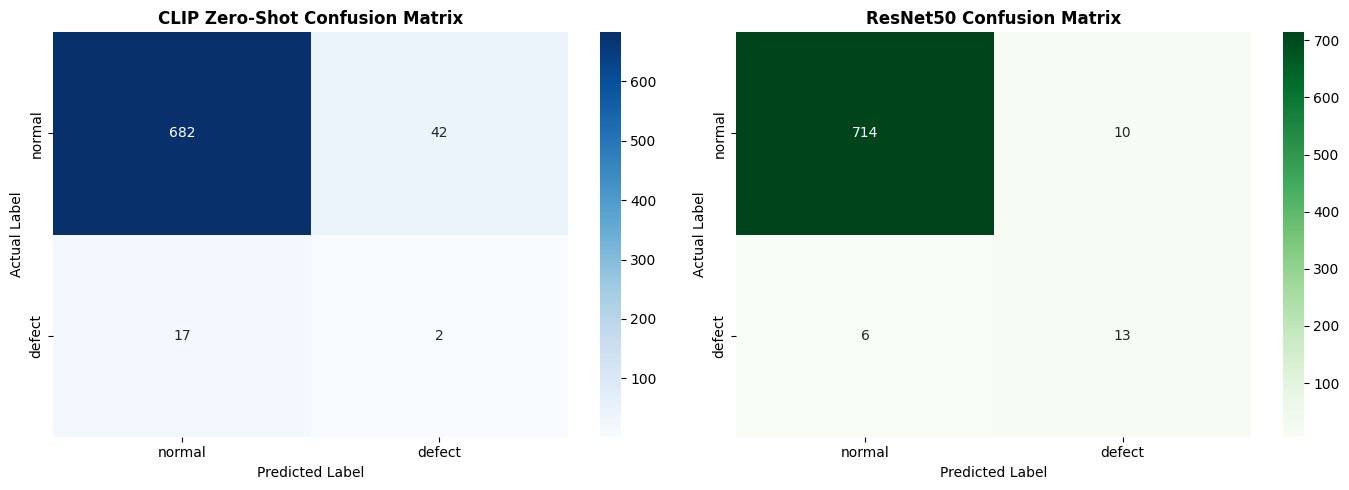

In [5]:
# Generate Confusion Matrices and plot heatmaps
clip_cm = confusion_matrix(true_labels, clip_predictions)
resnet_cm = confusion_matrix(true_labels, resnet_predictions)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot CLIP Confusion Matrix
sns.heatmap(clip_cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["normal", "defect"], yticklabels=["normal", "defect"], ax=axes[0])
axes[0].set_title("CLIP Zero-Shot Confusion Matrix", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("Actual Label")

# Plot ResNet50 Confusion Matrix
sns.heatmap(resnet_cm, annot=True, fmt="d", cmap="Greens", 
            xticklabels=["normal", "defect"], yticklabels=["normal", "defect"], ax=axes[1])
axes[1].set_title("ResNet50 Confusion Matrix", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("Actual Label")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "confusion_matrices.png"), dpi=150)
plt.show()


# 7. Precision Recall F1-score Report

Chỉ số Precision hay độ chính xác biểu thị tỷ lệ mẫu thực sự lỗi trong số các mẫu được mô hình dự đoán là lỗi. Chỉ số Recall hay độ nhạy biểu thị tỷ lệ mẫu lỗi được mô hình phát hiện thành công so với tổng số mẫu lỗi thực tế. Chỉ số F1 là trung bình điều hòa giữa Precision và Recall, giúp đánh giá toàn diện hiệu năng của mô hình trên tập dữ liệu mất cân bằng.

## Threshold Sensitivity Analysis
Phân tích độ nhạy của ngưỡng quyết định giúp nghiên cứu sự đánh đổi giữa Precision và Recall khi thay đổi ngưỡng phân loại. Việc lựa chọn ngưỡng tối ưu là vô cùng quan trọng đối với các hệ thống phát hiện lỗi sản phẩm trong thực tế nhằm cân đối giữa việc tối thiểu hóa lỗi bỏ sót sản phẩm khuyết tật và lỗi cảnh báo sai cho người dùng.


==================== CLIP CLASSIFICATION REPORT ====================
              precision    recall  f1-score   support

      normal       0.98      0.94      0.96       724
      defect       0.05      0.11      0.06        19

    accuracy                           0.92       743
   macro avg       0.51      0.52      0.51       743
weighted avg       0.95      0.92      0.94       743

================== RESNET50 CLASSIFICATION REPORT ==================
              precision    recall  f1-score   support

      normal       0.99      0.99      0.99       724
      defect       0.57      0.68      0.62        19

    accuracy                           0.98       743
   macro avg       0.78      0.84      0.80       743
weighted avg       0.98      0.98      0.98       743



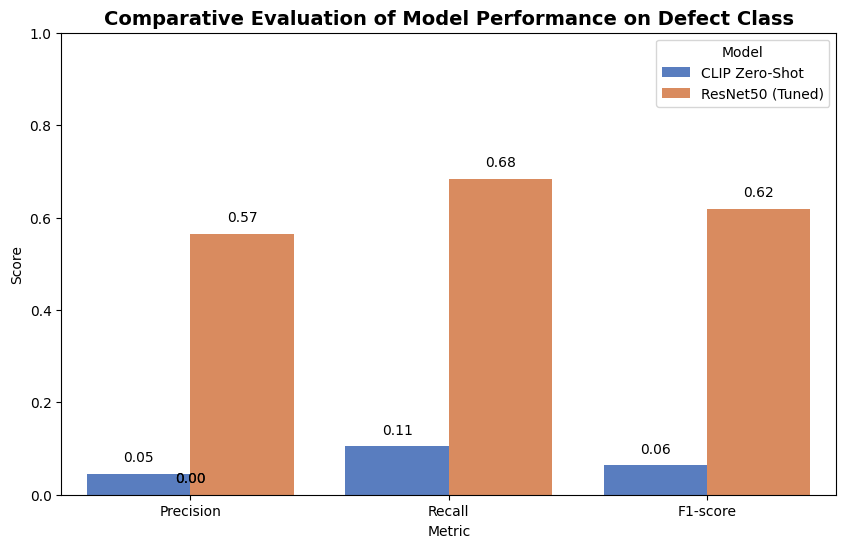

In [6]:
# Compute and print metrics, then plot comparative bar chart
clip_report = classification_report(true_labels, clip_predictions, target_names=["normal", "defect"])
resnet_report = classification_report(true_labels, resnet_predictions, target_names=["normal", "defect"])

print("==================== CLIP CLASSIFICATION REPORT ====================")
print(clip_report)
print("================== RESNET50 CLASSIFICATION REPORT ==================")
print(resnet_report)

# Extract metrics for plotting
clip_metrics = precision_recall_fscore_support(true_labels, clip_predictions, average=None)
resnet_metrics = precision_recall_fscore_support(true_labels, resnet_predictions, average=None)

clip_acc = accuracy_score(true_labels, clip_predictions)
resnet_acc = accuracy_score(true_labels, resnet_predictions)

# Focus on Defect class (index 1)
metrics_df = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-score"],
    "CLIP Zero-Shot": [clip_metrics[0][1], clip_metrics[1][1], clip_metrics[2][1]],
    "ResNet50 (Tuned)": [resnet_metrics[0][1], resnet_metrics[1][1], resnet_metrics[2][1]]
})

metrics_melted = pd.melt(metrics_df, id_vars="Metric", var_name="Model", value_name="Score")

plt.figure(figsize=(10, 6))
sns.barplot(data=metrics_melted, x="Metric", y="Score", hue="Model", palette="muted")
plt.title("Comparative Evaluation of Model Performance on Defect Class", fontsize=14, fontweight="bold")
plt.ylabel("Score")
plt.ylim(0, 1.0)
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height() + 0.02),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)
plt.savefig(os.path.join(output_dir, "model_comparison.png"), dpi=150)
plt.show()


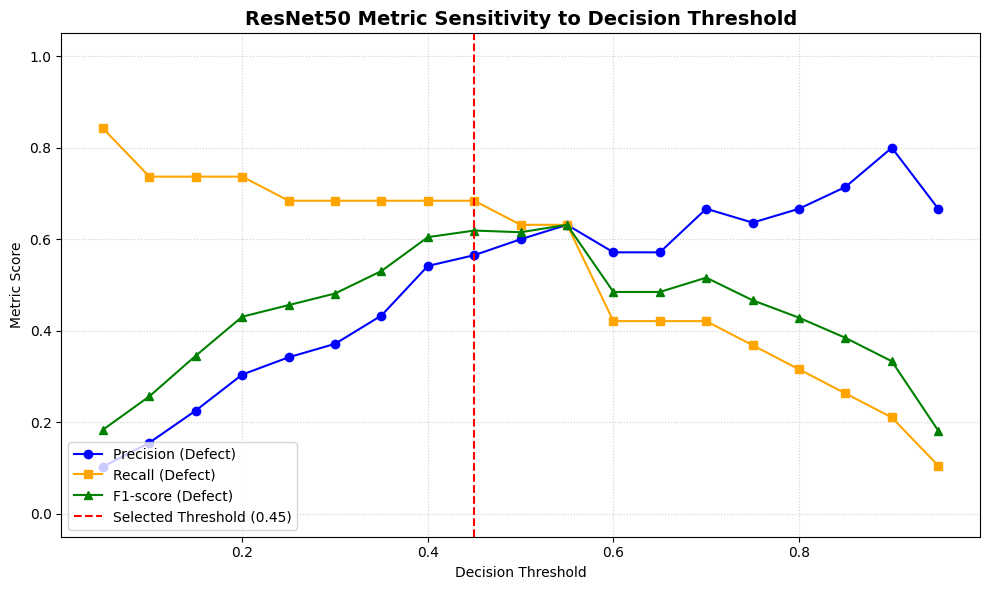

In [7]:
# Threshold sensitivity analysis sweep for ResNet50
thresholds = np.arange(0.05, 1.0, 0.05)
precisions = []
recalls = []
f1_scores = []

for t in thresholds:
    preds = [1 if p >= t else 0 for p in resnet_defect_probs]
    p_class, r_class, f_class, _ = precision_recall_fscore_support(
        true_labels, preds, average=None, zero_division=0
    )
    # Extract metrics for Defect class (index 1)
    precisions.append(p_class[1])
    recalls.append(r_class[1])
    f1_scores.append(f_class[1])

# Plot threshold sensitivity graph
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, label="Precision (Defect)", marker='o', color='blue')
plt.plot(thresholds, recalls, label="Recall (Defect)", marker='s', color='orange')
plt.plot(thresholds, f1_scores, label="F1-score (Defect)", marker='^', color='green')
plt.axvline(x=0.45, color='red', linestyle='--', label="Selected Threshold (0.45)")
plt.title("ResNet50 Metric Sensitivity to Decision Threshold", fontsize=14, fontweight="bold")
plt.xlabel("Decision Threshold")
plt.ylabel("Metric Score")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc="lower left")
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "threshold_sensitivity.png"), dpi=150)
plt.show()


# 8. False Positive and False Negative Extraction

Trong ngữ cảnh hệ thống phân tích đánh giá sản phẩm, lỗi False Positive xảy ra khi hình ảnh sản phẩm bình thường bị mô hình nhận diện nhầm là sản phẩm lỗi. Lỗi này có thể làm giảm trải nghiệm của người bán khi sản phẩm tốt bị cảnh báo sai. Lỗi False Negative xảy ra khi sản phẩm lỗi thực tế bị bỏ sót và bị phân loại là bình thường, điều này gây ảnh hưởng nghiêm trọng đến chất lượng kiểm soát sản phẩm của hệ thống.


In [8]:
# Create dataframes of predictions and label categories
results_df = pd.DataFrame({
    "image_path": image_paths,
    "true_label": true_labels,
    
    "clip_pred": clip_predictions,
    "clip_conf": clip_confidences,
    
    "resnet_pred": resnet_predictions,
    "resnet_conf": resnet_confidences
})

# Class label mappings for error reporting
label_name_mapping = {0: "normal", 1: "defect"}

# Build detailed error logs
clip_errors = []
resnet_errors = []

for idx, row in results_df.iterrows():
    img_path = row["image_path"]
    filename = os.path.basename(img_path)
    true_label_str = label_name_mapping[row["true_label"]]
    
    # Analyze CLIP errors
    if row["true_label"] != row["clip_pred"]:
        error_type = "false_positive" if row["clip_pred"] == 1 else "false_negative"
        pred_label_str = label_name_mapping[row["clip_pred"]]
        exported_name = f"{os.path.splitext(filename)[0]}__true-{true_label_str}__pred-{pred_label_str}__conf-{row['clip_conf']:.4f}.jpg"
        exported_path = os.path.join(output_dir, "clip", f"{error_type}s", exported_name)
        
        clip_errors.append({
            "image_path": img_path,
            "exported_path": exported_path,
            "model_name": "CLIP Zero-Shot",
            "true_label": true_label_str,
            "predicted_label": pred_label_str,
            "confidence_score": row["clip_conf"],
            "error_type": error_type,
            "optional_notes": "CLIP zero-shot classification error."
        })
        
    # Analyze ResNet50 errors
    if row["true_label"] != row["resnet_pred"]:
        error_type = "false_positive" if row["resnet_pred"] == 1 else "false_negative"
        pred_label_str = label_name_mapping[row["resnet_pred"]]
        exported_name = f"{os.path.splitext(filename)[0]}__true-{true_label_str}__pred-{pred_label_str}__conf-{row['resnet_conf']:.4f}.jpg"
        exported_path = os.path.join(output_dir, "resnet50", f"{error_type}s", exported_name)
        
        resnet_errors.append({
            "image_path": img_path,
            "exported_path": exported_path,
            "model_name": "ResNet50 (Tuned)",
            "true_label": true_label_str,
            "predicted_label": pred_label_str,
            "confidence_score": row["resnet_conf"],
            "error_type": error_type,
            "optional_notes": "ResNet50 prediction error."
        })

clip_errors_df = pd.DataFrame(clip_errors)
resnet_errors_df = pd.DataFrame(resnet_errors)

logger.info(f"Total CLIP Errors: {len(clip_errors_df)}")
if not clip_errors_df.empty:
    print(clip_errors_df["error_type"].value_counts())
    
logger.info(f"Total ResNet50 Errors: {len(resnet_errors_df)}")
if not resnet_errors_df.empty:
    print(resnet_errors_df["error_type"].value_counts())


2026-05-25 17:41:06,448 - INFO - Total CLIP Errors: 59


error_type
false_positive    42
false_negative    17
Name: count, dtype: int64
2026-05-25 17:41:06,451 - INFO - Total ResNet50 Errors: 16


error_type
false_positive    10
false_negative     6
Name: count, dtype: int64


# 9. Error Sample Export

Quá trình tự động xuất các mẫu ảnh dự đoán sai giúp các kỹ sư dữ liệu dễ dàng kiểm tra trực quan các lỗi hệ thống. Các tệp tin được phân loại vào các thư mục riêng biệt dựa trên loại lỗi và mô hình dự đoán. Tên tệp tin xuất ra được đặt theo định dạng chuẩn chứa tên gốc, nhãn thực tế, nhãn dự đoán và điểm tin cậy để thuận tiện cho việc tra cứu.

## Wrong Classes Folder Clarification
Thư mục wrong_classes được khởi tạo nhằm mục đích dự phòng cho các mở rộng phân loại đa lớp trong tương lai. Do mô hình ResNet50 hiện tại hoạt động dưới dạng phân loại nhị phân giữa hai lớp bình thường và lỗi, thư mục này sẽ tạm thời không chứa dữ liệu xuất ra. Các mẫu dự đoán sai hiện tại được phân loại hoàn toàn vào hai nhóm false_positives và false_negatives.


In [9]:
# Export misclassified images and create CSV error reports
logger.info("Exporting CLIP error images...")
for idx, row in clip_errors_df.iterrows():
    if os.path.exists(row["image_path"]):
        shutil.copy2(row["image_path"], row["exported_path"])
    else:
        logger.warning(f"Error image not found for export: {row['image_path']}")

logger.info("Exporting ResNet50 error images...")
for idx, row in resnet_errors_df.iterrows():
    if os.path.exists(row["image_path"]):
        shutil.copy2(row["image_path"], row["exported_path"])
    else:
        logger.warning(f"Error image not found for export: {row['image_path']}")

# Save reports to CSV
clip_errors_df.to_csv(os.path.join(output_dir, "clip_error_report.csv"), index=False, encoding="utf-8-sig")
resnet_errors_df.to_csv(os.path.join(output_dir, "resnet50_error_report.csv"), index=False, encoding="utf-8-sig")

logger.info("Error CSV reports saved successfully.")


2026-05-25 17:41:06,458 - INFO - Exporting CLIP error images...


2026-05-25 17:41:06,550 - INFO - Exporting ResNet50 error images...


2026-05-25 17:41:06,579 - INFO - Error CSV reports saved successfully.


# 10. Visual Error Inspection

Việc hiển thị lưới hình ảnh các mẫu lỗi tiêu biểu giúp xác định trực quan các yếu tố gây nhiễu cho mô hình. Các mẫu ảnh dự đoán sai của cả hai mô hình được trực quan hóa kèm theo các thông số dự đoán để hỗ trợ việc phân tích nguyên nhân lỗi ở bước tiếp theo.


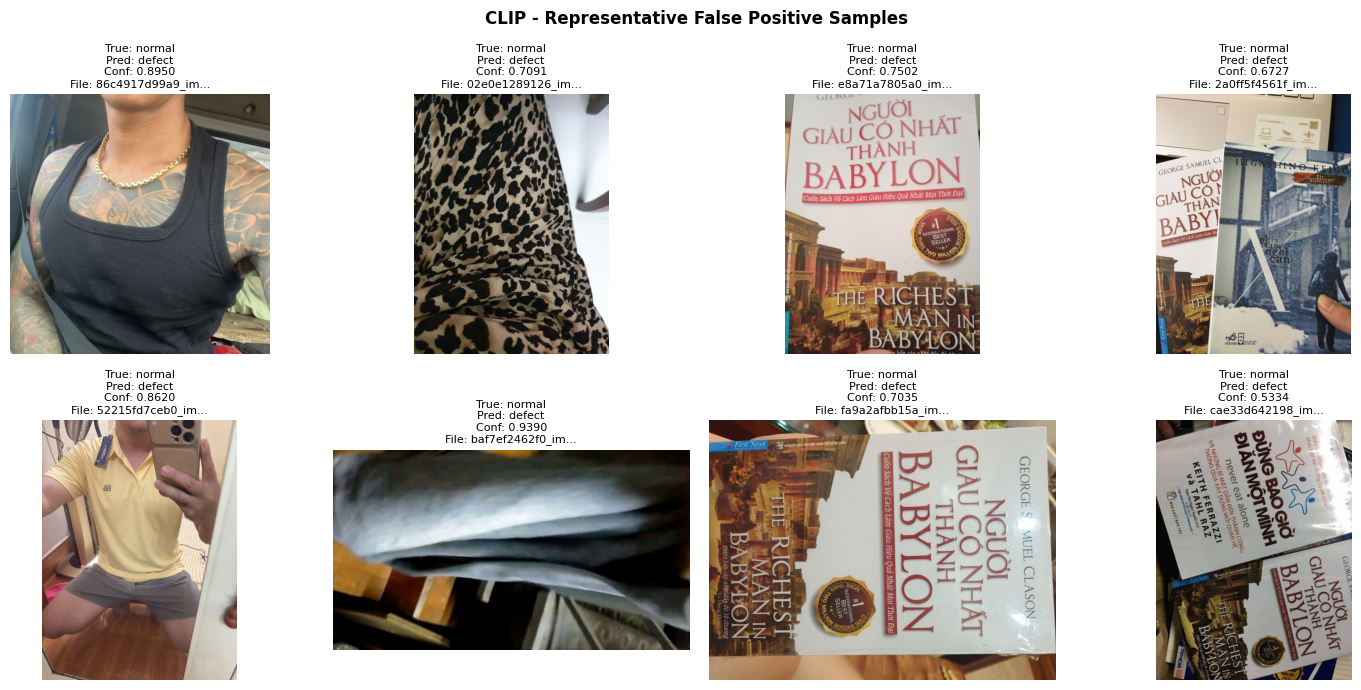

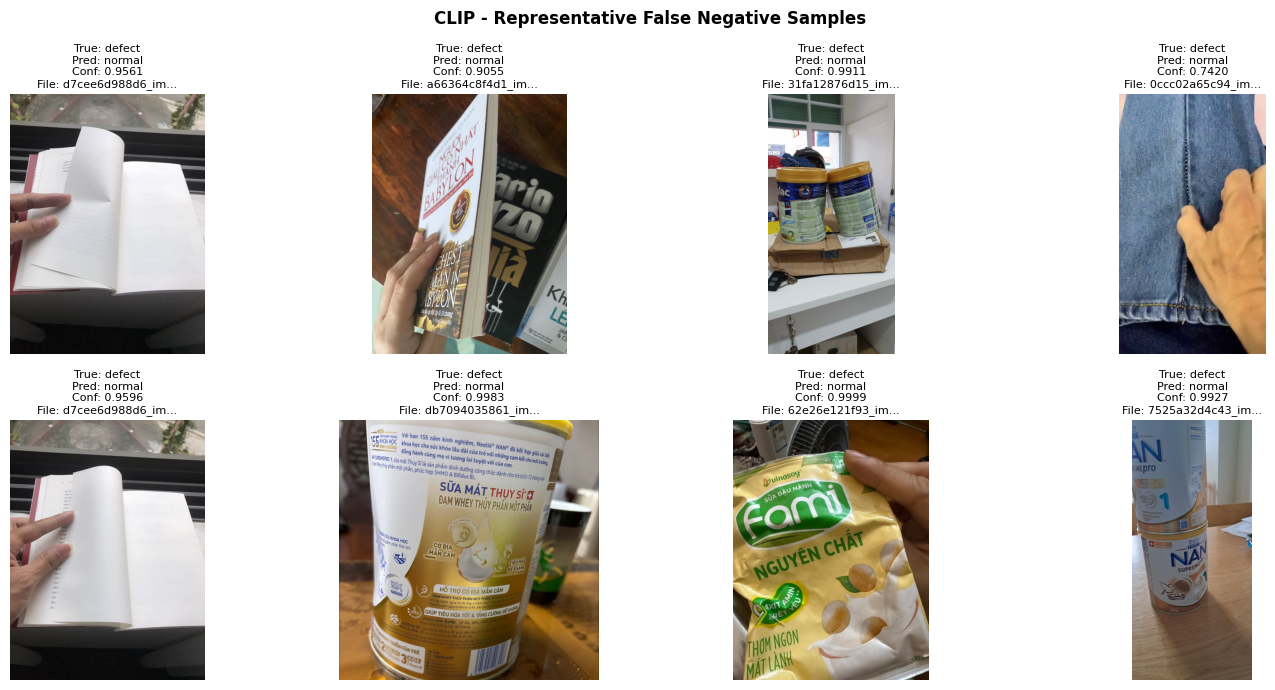

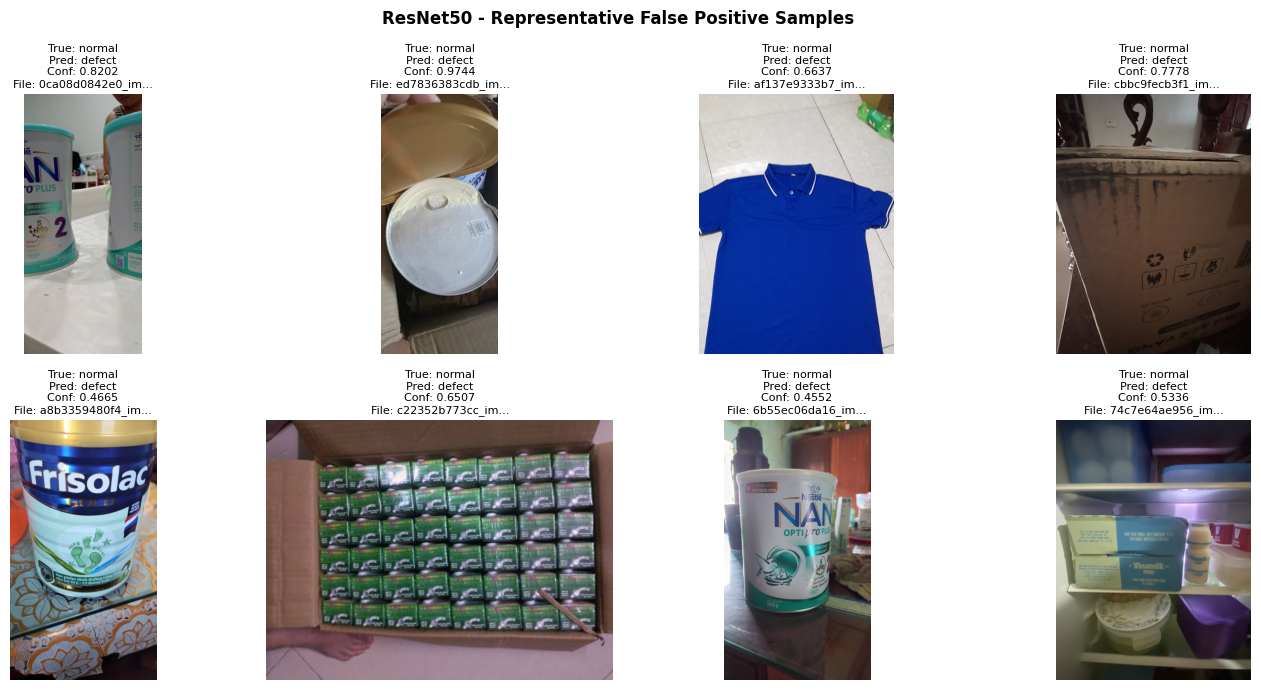

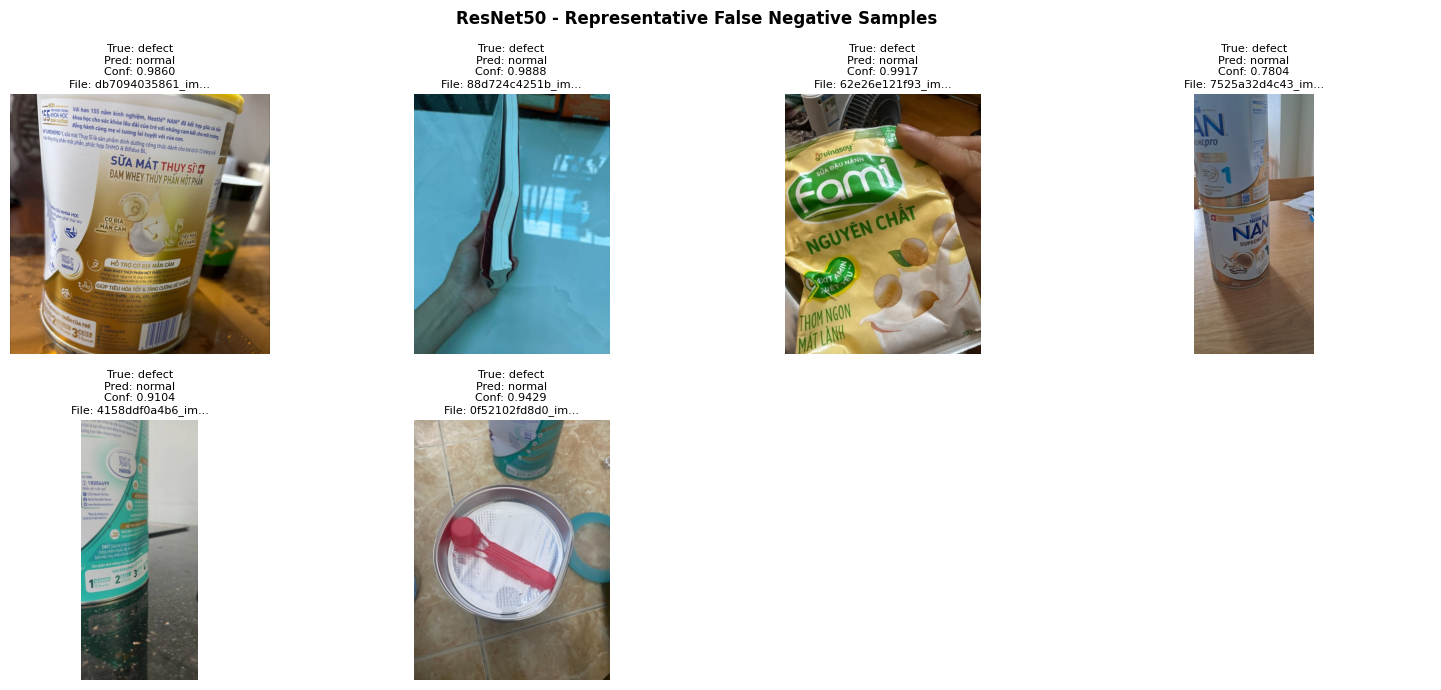

In [10]:
# Helper to plot a grid of representative misclassifications
def plot_error_grid(error_df, title, max_images=8):
    if error_df.empty:
        logger.info(f"No error samples found to display for: {title}")
        return
        
    samples = error_df.head(max_images)
    num_samples = len(samples)
    
    cols = min(4, num_samples)
    rows = (num_samples + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3.5 * rows))
    
    if rows == 1 and cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for i, (_, row) in enumerate(samples.iterrows()):
        try:
            if not os.path.exists(row["image_path"]):
                axes[i].axis('off')
                axes[i].set_title("Missing File", fontsize=8)
                continue
            img = Image.open(row["image_path"])
            axes[i].imshow(img)
            axes[i].axis('off')
            axes[i].set_title(
                f"True: {row['true_label']}\nPred: {row['predicted_label']}\nConf: {row['confidence_score']:.4f}\nFile: {os.path.basename(row['image_path'])[:15]}...",
                fontsize=8
            )
        except Exception as e:
            axes[i].axis('off')
            axes[i].set_title(f"Error loading image:\n{e}", fontsize=8)
            
    # Hide any unused subplots
    for j in range(num_samples, len(axes)):
        axes[j].axis('off')
        
    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Display CLIP representative error grids
if not clip_errors_df.empty:
    plot_error_grid(clip_errors_df[clip_errors_df["error_type"] == "false_positive"], "CLIP - Representative False Positive Samples")
    plot_error_grid(clip_errors_df[clip_errors_df["error_type"] == "false_negative"], "CLIP - Representative False Negative Samples")

# Display ResNet50 representative error grids
if not resnet_errors_df.empty:
    plot_error_grid(resnet_errors_df[resnet_errors_df["error_type"] == "false_positive"], "ResNet50 - Representative False Positive Samples")
    plot_error_grid(resnet_errors_df[resnet_errors_df["error_type"] == "false_negative"], "ResNet50 - Representative False Negative Samples")


### Nhận xét phân tích về các lỗi trực quan
Dựa trên hình ảnh thực tế từ các mẫu dự đoán sai, ta có thể phân loại các nguyên nhân lỗi thị giác thành các nhóm cụ thể sau:
- Thứ nhất, nhóm ảnh thiếu sáng hoặc lóa sáng làm mờ đặc trưng lỗi.
- Thứ hai, nhóm lỗi bị che khuất một phần bởi góc chụp hoặc tay người cầm.
- Thứ ba, nhóm ảnh có hậu cảnh phức tạp chứa nhiều chi tiết gây nhiễu làm mô hình nhận diện sai chủ thể.
- Thứ tư, nhóm lỗi có kích thước quá nhỏ so với toàn bộ khung hình khiến các lớp tích chập bỏ sót đặc trưng biên.
- Thứ năm, nhóm ảnh có độ phân giải thấp làm mất các chi tiết cạnh sắc nét.
- Thứ sáu, nhóm nhãn sản phẩm tương đồng về mặt thị giác khiến mô hình CLIP phân loại nhầm.


# 11. Explainability Analysis with Grad-CAM

Khả năng giải thích của mô hình học sâu là yếu tố then chốt để xây dựng sự tin cậy trong các ứng dụng thực tế. Phương pháp Grad-CAM sử dụng dòng đạo hàm từ lớp phân loại cuối cùng quay lại các bản đồ kích hoạt của lớp tích chập cuối cùng để xác định các vùng pixel đóng vai trò quyết định trong việc đưa ra nhãn dự báo lỗi. Phần phân tích dưới đây trực quan hóa các vùng chú ý này của mạng ResNet50 trên một số trường hợp tiêu biểu.


2026-05-25 17:41:09,546 - INFO - Visualizing Grad-CAM explainability for representative defect samples...


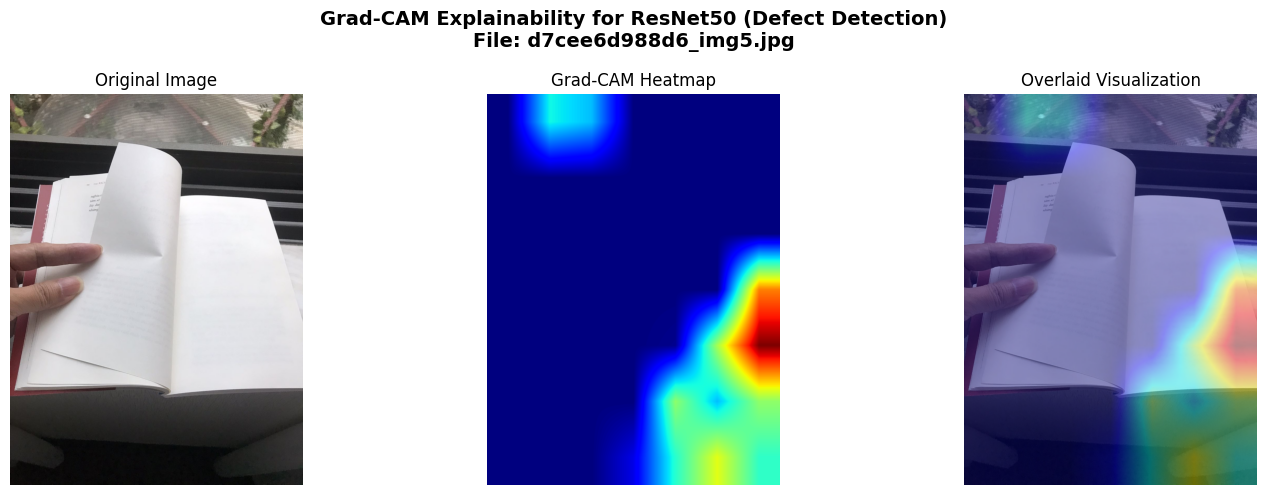

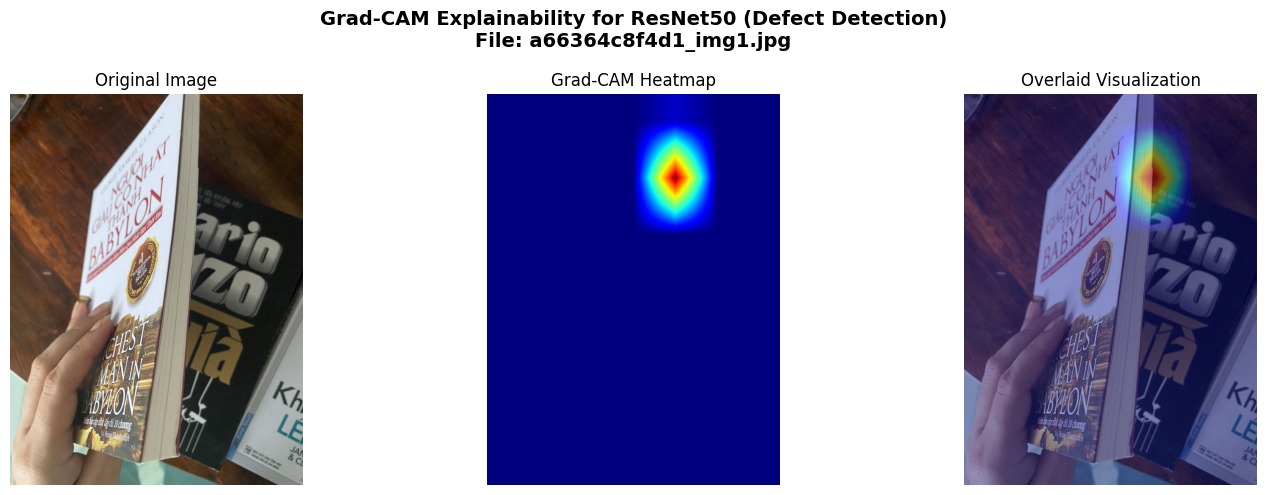

In [11]:
# Hook-based Grad-CAM implementation for ResNet50
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
from ai_engine.image_processing.defect_detection import _load_resnet_model

class ResNetGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.forward_hook = target_layer.register_forward_hook(self.save_activation)
        self.backward_hook = target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()

    def generate_heatmap(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        output = self.model(input_tensor)
        
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
            
        loss = output[0, class_idx]
        loss.backward()
        
        if self.gradients is None:
            raise ValueError("Gradients were not computed. Ensure backward hooks are active.")
            
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        
        activations = self.activations.clone()
        for i in range(activations.shape[1]):
            activations[:, i, :, :] *= pooled_gradients[i]
            
        heatmap = torch.mean(activations, dim=1).squeeze()
        heatmap = np.maximum(heatmap.cpu().numpy(), 0)
        
        max_val = np.max(heatmap)
        if max_val > 0:
            heatmap /= max_val
            
        return heatmap

def visualize_resnet_gradcam(image_path, model_path, device, class_idx=None):
    if not os.path.exists(image_path):
        logger.warning(f"Image for Grad-CAM not found: {image_path}")
        return
        
    try:
        model = _load_resnet_model(model_path=model_path, device=device)
        for param in model.parameters():
            param.requires_grad = True
            
        target_layer = model.layer4[-1]
        gradcam = ResNetGradCAM(model, target_layer)
        
        preprocess = A.Compose([
            A.Resize(224, 224),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ])
        
        image_bgr = cv2.imread(image_path)
        if image_bgr is None:
            raise ValueError(f"Failed to read image: {image_path}")
            
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        h, w, _ = image_rgb.shape
        
        transformed = preprocess(image=image_rgb)
        image_tensor = transformed["image"].unsqueeze(0).to(device)
        image_tensor.requires_grad = True
        
        heatmap = gradcam.generate_heatmap(image_tensor, class_idx=class_idx)
        gradcam.remove_hooks()
        
        # Restore model parameter flags
        for param in model.parameters():
            param.requires_grad = False
        for param in model.fc.parameters():
            param.requires_grad = True
            
        # Overlay heatmap on original image
        heatmap_resized = cv2.resize(heatmap, (w, h))
        colormap = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
        colormap_rgb = cv2.cvtColor(colormap, cv2.COLOR_BGR2RGB)
        overlaid = cv2.addWeighted(image_rgb, 0.6, colormap_rgb, 0.4, 0)
        
        # Plot
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(image_rgb)
        axes[0].set_title("Original Image")
        axes[0].axis("off")
        
        axes[1].imshow(heatmap_resized, cmap="jet")
        axes[1].set_title("Grad-CAM Heatmap")
        axes[1].axis("off")
        
        axes[2].imshow(overlaid)
        axes[2].set_title("Overlaid Visualization")
        axes[2].axis("off")
        
        plt.suptitle(f"Grad-CAM Explainability for ResNet50 (Defect Detection)\nFile: {os.path.basename(image_path)}", fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        logger.error(f"Grad-CAM visualization failed for {image_path}: {e}")

# Select representative defect images from validation set
defect_indices = [idx for idx, label in enumerate(true_labels) if label == 1]
if len(defect_indices) > 0:
    logger.info("Visualizing Grad-CAM explainability for representative defect samples...")
    # Visualize the first two defect samples
    for idx in defect_indices[:2]:
        visualize_resnet_gradcam(image_paths[idx], resnet_model_path, device, class_idx=1)


# 12. Root Cause Analysis

Phân tích nguyên nhân lỗi cho thấy các sai lệch dự đoán xuất phát từ nhiều nhóm nguyên nhân chính dưới đây:

Thứ nhất, sai lệch do chất lượng ảnh đầu vào bao gồm các ảnh bị mờ do rung tay, ảnh thiếu sáng hoặc ảnh bị lóa sáng mạnh làm mất đi các chi tiết lỗi vật lý.

Thứ hai, sai lệch do góc chụp và vùng lỗi bị che khuất xảy ra khi các khuyết tật của sản phẩm nằm ở mặt sau hoặc bị tay của người dùng che lấp trong ảnh đánh giá.

Thứ ba, sai lệch do độ phân giải thấp hoặc chi tiết lỗi có kích thước nhỏ làm cho mô hình tích chập không thể trích xuất được đặc trưng của các vết xước nhỏ hoặc các lỗi nhỏ trên bề mặt sản phẩm.

Thứ tư, sai lệch do nhiễu nền và vật thể không liên quan xuất hiện khi hậu cảnh quá phức tạp hoặc có các vật dụng sinh hoạt khác lấn át chủ thể sản phẩm cần đánh giá.

Thứ lý, sai lệch do prompt CLIP chưa bao quát đầy đủ ngữ nghĩa ảnh khiến mô hình zero shot không hiểu được các ngữ cảnh phức tạp của ảnh đánh giá tại Việt Nam.

Thứ sáu, sai lệch do ngưỡng tin cậy chưa phù hợp dẫn đến việc mô hình phân loại sai các mẫu nằm ở ranh giới quyết định.

Thứ bảy, sai lệch do mất cân bằng dữ liệu giữa các lớp khi số lượng ảnh sản phẩm lỗi quá ít so với ảnh sản phẩm bình thường làm cho mô hình có xu hướng thiên vị lớp đa số.

Thứ tám, sai lệch do đặc trưng thị giác giữa các lớp có mức tương đồng cao khiến mô hình khó phân biệt giữa các sản phẩm có bề mặt nhám tự nhiên và sản phẩm bị trầy xước thực tế.


# 13. Improvement Recommendations

Để nâng cao chất lượng dự đoán của hệ thống, các đề xuất cải thiện cụ thể bao gồm:

Đầu tiên là cải thiện các mẫu mô tả cho CLIP bằng cách bổ sung các từ khóa tiếng Anh chi tiết hơn và tối ưu hóa các cụm từ mô tả ngữ cảnh ảnh đánh giá.

Thứ hai là tinh chỉnh ngưỡng ra quyết định cho cả mô hình CLIP và ResNet50 để cân bằng giữa độ chính xác và độ nhạy dựa trên yêu cầu thực tế của hệ thống.

Thứ ba là áp dụng các phương pháp tăng cường dữ liệu mục tiêu như làm mờ, xoay ảnh, thay đổi độ sáng và tạo nhiễu để nâng cao khả năng chống chịu của ResNet50 trước các biến động của ảnh đầu vào.

Thứ tư là bổ sung thêm các mẫu ảnh cho lớp sản phẩm lỗi để giảm thiểu tác động của việc mất cân bằng dữ liệu nghiêm trọng.

Thứ năm là kiểm tra lại chất lượng nhãn của tập dữ liệu kiểm thử để loại bỏ các trường hợp gắn nhãn sai từ người dùng.

Cuối cùng là nghiên cứu tích hợp phương pháp giải thích trực quan như Grad-CAM để hiểu rõ vùng tập trung đặc trưng của mô hình ResNet50 khi đưa ra quyết định.


# 14. Conclusion

Tổng kết lại, nghiên cứu đánh giá chéo đã chỉ ra sự khác biệt rõ rệt về hiệu năng và độ tin cậy giữa mô hình CLIP và mô hình ResNet50. Mô hình ResNet50 sau tinh chỉnh thể hiện độ tin cậy vượt trội trong việc nhận diện các lỗi vật lý cụ thể trên sản phẩm nhờ khả năng trích xuất các đặc trưng thị giác chi tiết từ quá trình học chuyển tiếp. Ngược lại, mô hình CLIP hoạt động ở dạng zero shot gặp nhiều hạn chế do tính tổng quát của các mô tả văn bản và không thể phân biệt được các chi tiết bất thường nhỏ trên bề mặt sản phẩm.

Về mặt vận hành, hạn chế lớn nhất của hệ thống là nguy cơ bỏ sót lỗi do tỷ lệ false negative vẫn còn tồn tại. Lỗi này dẫn đến việc sản phẩm lỗi bị phân loại nhầm là sản phẩm tốt, gây ảnh hưởng trực tiếp đến quy trình kiểm soát chất lượng tự động. Trong thực tế triển khai, việc kết hợp hai mô hình theo kiến trúc phân tầng là giải pháp tối ưu, trong đó mô hình CLIP được sử dụng làm bộ lọc sơ bộ để loại bỏ ảnh rác trước khi ResNet50 thực hiện nhận diện lỗi chi tiết.

Hướng phát triển tương lai sẽ tập trung vào việc huấn luyện đồng thời cả hai mô hình trên tập dữ liệu lớn hơn kết hợp với các kỹ thuật tăng cường dữ liệu đặc thù. Việc áp dụng các chiến lược kết hợp nhóm mô hình hoặc tích hợp các công cụ giải thích mô hình như Grad-CAM sẽ giúp các kỹ sư hiểu rõ các vùng tập trung đặc trưng thị giác khi mô hình đưa ra quyết định, từ đó nâng cao tính minh bạch và độ chính xác của hệ thống.
